# 시계열 전처리: RevIN 정규화 + 패치 시퀀스 생성

**입력**: `data/kospi_valid.parquet` (781종목, ~118만 행)  
**출력**: `data/sequences/` — train/val/test 별 `.npz` 시퀀스 파일

**파이프라인**
```
수정종가(Adj_Close) + 기술적 지표
    → RevIN 정규화 (인스턴스 단위)
    → 슬라이딩 윈도우 (입력 60일 / 예측 5일)
    → 패치 단위 분리 (5일 1패치 → 12패치 입력)
    → train / val / test .npz 저장
```

## 0. 설정

In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 110

OUT_DIR = Path('data/sequences')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── 핵심 하이퍼파라미터 ──────────────────────────────
SEQ_LEN   = 60   # 입력 윈도우 (영업일)
PRED_LEN  = 5    # 예측 구간 (영업일, 1주일)
PATCH_LEN = 5    # 패치 크기 (Chronos 방식)
STRIDE    = 1    # 슬라이딩 스텝

TRAIN_END = '2024-06-30'   # train 마지막 날
VAL_END   = '2024-12-31'   # val 마지막 날
# test: 2025-01-01 ~

# 입력 피처 선택
PRICE_COLS = ['Adj_Close', 'Open', 'High', 'Low', 'Volume']
TECH_COLS  = [
    'SMA_5', 'SMA_20', 'SMA_60',
    'EMA_12', 'EMA_26',
    'MACD', 'MACD_signal', 'MACD_hist',
    'RSI_14',
    'BB_width',
    'Volume_ratio',
    'Return_1d', 'Return_5d',
    'Volatility_20d',
    'ATR_14',
]
FEATURE_COLS = PRICE_COLS + TECH_COLS
N_FEATURES = len(FEATURE_COLS)

print(f'피처 수: {N_FEATURES}')
print(f'피처 목록: {FEATURE_COLS}')
print(f'\n입력 길이: {SEQ_LEN}일 = {SEQ_LEN // PATCH_LEN}패치')
print(f'예측 길이: {PRED_LEN}일')

/Users/seungbin/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


피처 수: 20
피처 목록: ['Adj_Close', 'Open', 'High', 'Low', 'Volume', 'SMA_5', 'SMA_20', 'SMA_60', 'EMA_12', 'EMA_26', 'MACD', 'MACD_signal', 'MACD_hist', 'RSI_14', 'BB_width', 'Volume_ratio', 'Return_1d', 'Return_5d', 'Volatility_20d', 'ATR_14']

입력 길이: 60일 = 12패치
예측 길이: 5일


## 1. 데이터 로드

In [3]:
df = pd.read_parquet('data/kospi_valid.parquet')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['종목코드', 'Date']).reset_index(drop=True)

print(f'전체: {len(df):,}행 | {df["종목코드"].nunique()}종목')
print(f'기간: {df.Date.min().date()} ~ {df.Date.max().date()}')
print(f'결측 (FEATURE_COLS): {df[FEATURE_COLS].isnull().sum().sum():,}개')

전체: 1,180,271행 | 781종목
기간: 2020-01-02 ~ 2026-05-04
결측 (FEATURE_COLS): 136,805개


## 2. RevIN (Reversible Instance Normalization)

In [4]:
class RevIN:
    """
    Reversible Instance Normalization (Kim et al., ICLR 2022)
    - 각 시퀀스 인스턴스 단위로 평균/분산 정규화
    - 예측 후 역변환(denormalize)으로 원래 스케일 복원 가능
    """
    def __init__(self, eps: float = 1e-8):
        self.eps = eps
        self.mean = None
        self.std  = None

    def normalize(self, x: np.ndarray) -> np.ndarray:
        # x: (seq_len, n_features)
        self.mean = np.nanmean(x, axis=0, keepdims=True)   # (1, n_features)
        self.std  = np.nanstd(x,  axis=0, keepdims=True) + self.eps
        return (x - self.mean) / self.std

    def denormalize(self, x_norm: np.ndarray) -> np.ndarray:
        return x_norm * self.std + self.mean


# 동작 확인
dummy = np.random.randn(60, N_FEATURES) * 1000 + 50000
revin = RevIN()
normed = revin.normalize(dummy)
restored = revin.denormalize(normed)

print(f'정규화 전  — mean: {dummy.mean():.1f}, std: {dummy.std():.1f}')
print(f'정규화 후  — mean: {normed.mean():.4f}, std: {normed.std():.4f}')
print(f'역변환 오차 — max|diff|: {np.abs(dummy - restored).max():.2e}')

정규화 전  — mean: 49955.0, std: 962.0
정규화 후  — mean: 0.0000, std: 1.0000
역변환 오차 — max|diff|: 0.00e+00


## 3. 결측값 처리

In [5]:
# 기술적 지표 초기 NaN: 윈도우 크기만큼 forward fill 후 남은 것은 0으로
df[FEATURE_COLS] = (
    df.groupby('종목코드')[FEATURE_COLS]
    .transform(lambda g: g.ffill().bfill().fillna(0))
)

# 타겟 컬럼 결측 확인 (시퀀스 끝부분 자연 발생 — 나중에 마스킹)
target_null = df[['Target_1d', 'Target_5d', 'RetTarget_1d']].isnull().sum()
print('타겟 결측:')
print(target_null)
print(f'\n피처 결측 (처리 후): {df[FEATURE_COLS].isnull().sum().sum()}')

타겟 결측:
Target_1d         0
Target_5d         0
RetTarget_1d    781
dtype: int64

피처 결측 (처리 후): 0


## 4. 슬라이딩 윈도우 + RevIN 적용

In [7]:
def make_sequences(stock_df: pd.DataFrame,
                   feature_cols: list,
                   seq_len: int,
                   pred_len: int,
                   stride: int = 1):
    """
    단일 종목 DataFrame → 슬라이딩 윈도우 시퀀스 생성 + RevIN 정규화

    Returns
    -------
    X       : (N, seq_len, n_features)  — RevIN 정규화된 입력
    y_ret   : (N,)  — 예측 구간 수익률 (회귀 타겟)
    y_dir   : (N,)  — 방향성 레이블 0/1 (분류 타겟)
    means   : (N, n_features)  — RevIN mean (역변환용)
    stds    : (N, n_features)  — RevIN std  (역변환용)
    dates   : (N,)  — 시퀀스 마지막 날짜 (기준 날짜)
    """
    arr = stock_df[feature_cols].values.astype(np.float32)
    dates = stock_df['Date'].values

    # PRED_LEN 일 후 수익률: (Close[t+pred_len] - Close[t]) / Close[t]
    close_idx = feature_cols.index('Adj_Close')

    X_list, y_ret_list, y_dir_list = [], [], []
    mean_list, std_list, date_list = [], [], []

    total = len(arr)
    for start in range(0, total - seq_len - pred_len + 1, stride):
        end = start + seq_len

        x_window = arr[start:end].copy()

        # RevIN 정규화
        revin = RevIN()
        x_norm = revin.normalize(x_window)

        # 타겟: 예측 구간 마지막 날 수익률
        p_now  = arr[end - 1, close_idx]
        p_fut  = arr[end + pred_len - 1, close_idx]
        ret    = (p_fut - p_now) / (p_now + 1e-8)
        direction = int(ret > 0)

        X_list.append(x_norm)
        y_ret_list.append(ret)
        y_dir_list.append(direction)
        mean_list.append(revin.mean[0])
        std_list.append(revin.std[0])
        date_list.append(dates[end - 1])

    if not X_list:
        return None

    return (
        np.stack(X_list),
        np.array(y_ret_list, dtype=np.float32),
        np.array(y_dir_list, dtype=np.int8),
        np.stack(mean_list),
        np.stack(std_list),
        np.array(date_list),
    )

# 단일 종목 테스트
test_stock = df[df['종목코드'] == df['종목코드'].iloc[0]].head(200)
result = make_sequences(test_stock, FEATURE_COLS, SEQ_LEN, PRED_LEN)
if result:
    X, y_ret, y_dir, means, stds, dates = result
    print(f'X shape: {X.shape}  → (시퀀스 수, {SEQ_LEN}일, {N_FEATURES}피처)')
    print(f'y_ret shape: {y_ret.shape}, y_dir shape: {y_dir.shape}')
    print(f'X 정규화 확인 — mean: {X.mean():.4f}, std: {X.std():.4f}')
    print(f'방향성 레이블 상승 비율: {y_dir.mean():.3f}')

X shape: (136, 60, 20)  → (시퀀스 수, 60일, 20피처)
y_ret shape: (136,), y_dir shape: (136,)
X 정규화 확인 — mean: -0.0000, std: 0.9998
방향성 레이블 상승 비율: 0.625


## 5. 패치 단위 분리 (Chronos 방식)

In [8]:
def to_patches(X: np.ndarray, patch_len: int) -> np.ndarray:
    """
    X: (N, seq_len, n_features)
    → patches: (N, n_patches, patch_len, n_features)

    seq_len=60, patch_len=5 → n_patches=12
    """
    N, T, F = X.shape
    assert T % patch_len == 0, f'seq_len({T})이 patch_len({patch_len})으로 나누어져야 합니다'
    n_patches = T // patch_len
    return X.reshape(N, n_patches, patch_len, F)


# 검증
X_patches = to_patches(X, PATCH_LEN)
print(f'패치 변환: {X.shape} → {X_patches.shape}')
print(f'  → (N={X_patches.shape[0]}, n_patches={X_patches.shape[1]}, '
      f'patch_len={X_patches.shape[2]}, n_features={X_patches.shape[3]})')

패치 변환: (136, 60, 20) → (136, 12, 5, 20)
  → (N=136, n_patches=12, patch_len=5, n_features=20)


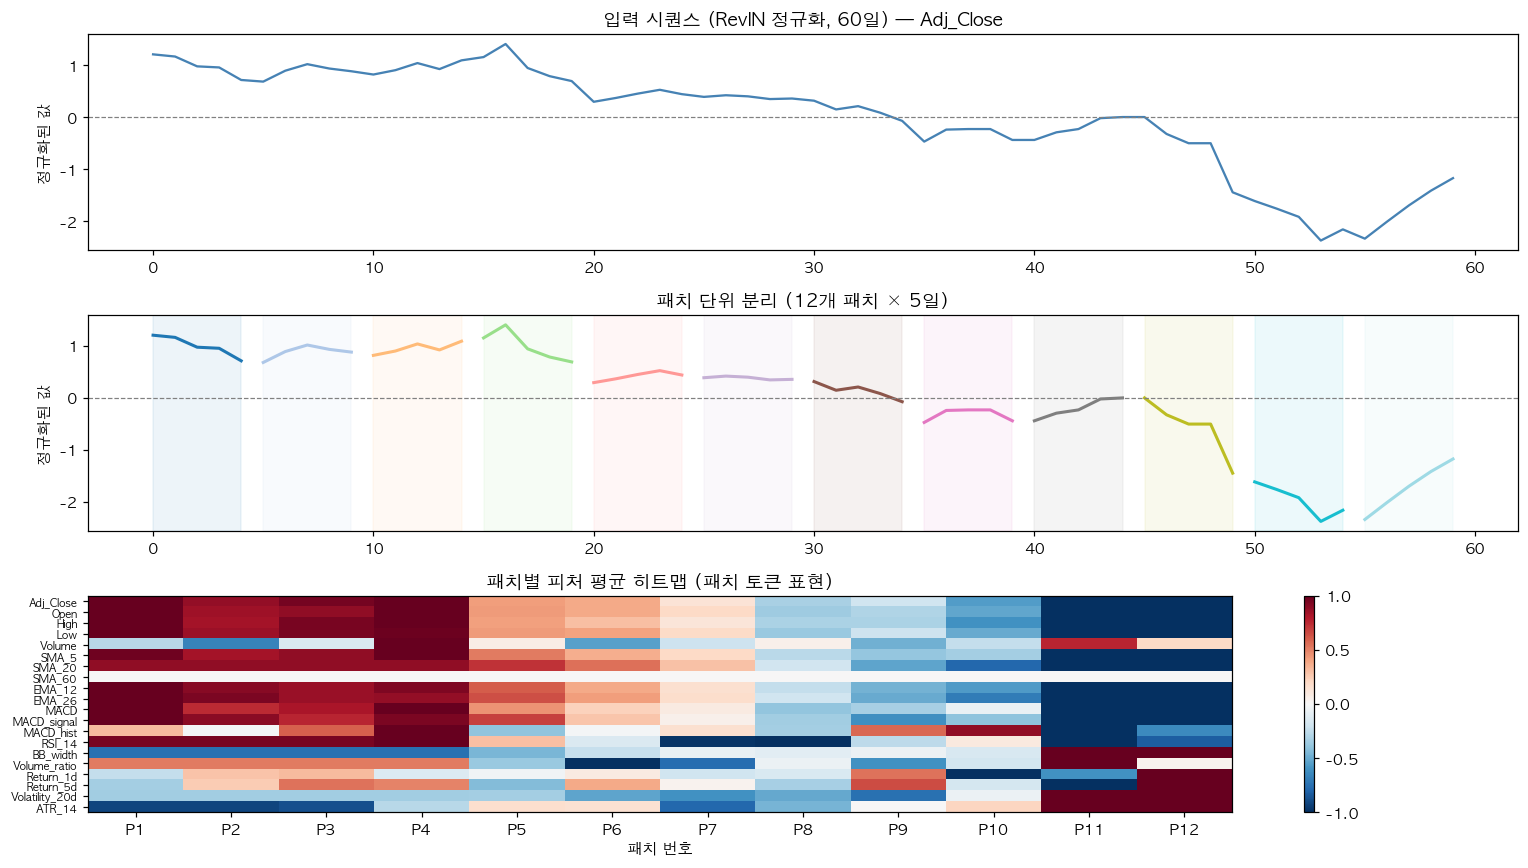

In [9]:
# 패치 구조 시각화 (직관적 이해)
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=False)

sample_idx = 0
adj_close_idx = FEATURE_COLS.index('Adj_Close')

# 원본 시퀀스
ax = axes[0]
seq_raw = X[sample_idx, :, adj_close_idx]
ax.plot(seq_raw, color='steelblue', lw=1.5)
ax.set_title(f'입력 시퀀스 (RevIN 정규화, {SEQ_LEN}일) — Adj_Close')
ax.set_ylabel('정규화된 값')
ax.axhline(0, color='gray', lw=0.8, linestyle='--')

# 패치로 분리
ax = axes[1]
colors = plt.cm.tab20(np.linspace(0, 1, SEQ_LEN // PATCH_LEN))
for i in range(SEQ_LEN // PATCH_LEN):
    start, end = i * PATCH_LEN, (i + 1) * PATCH_LEN
    ax.plot(range(start, end), seq_raw[start:end], color=colors[i], lw=2)
    ax.axvspan(start, end - 1, alpha=0.08, color=colors[i])
ax.set_title(f'패치 단위 분리 ({SEQ_LEN // PATCH_LEN}개 패치 × {PATCH_LEN}일)')
ax.set_ylabel('정규화된 값')
ax.axhline(0, color='gray', lw=0.8, linestyle='--')

# 모든 피처의 패치별 평균 (패치 토큰 시각화)
ax = axes[2]
patch_means = X_patches[sample_idx].mean(axis=1)  # (n_patches, n_features)
im = ax.imshow(patch_means.T, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(SEQ_LEN // PATCH_LEN))
ax.set_xticklabels([f'P{i+1}' for i in range(SEQ_LEN // PATCH_LEN)])
ax.set_yticks(range(N_FEATURES))
ax.set_yticklabels(FEATURE_COLS, fontsize=7)
ax.set_title('패치별 피처 평균 히트맵 (패치 토큰 표현)')
ax.set_xlabel('패치 번호')
plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

## 6. 전체 종목 처리 + Train/Val/Test 분할 저장

In [10]:
def build_split_sequences(df: pd.DataFrame,
                          feature_cols: list,
                          seq_len: int,
                          pred_len: int,
                          patch_len: int,
                          train_end: str,
                          val_end: str,
                          stride: int = 1):
    """
    전체 종목 순회 → split별 시퀀스 수집
    시간 누수 방지: 날짜 기준으로 슬라이드하되,
    각 시퀀스의 마지막 날이 해당 split 기간 내에 속하는 것만 포함
    """
    train_end_dt = pd.Timestamp(train_end)
    val_end_dt   = pd.Timestamp(val_end)

    splits = {'train': [], 'val': [], 'test': []}
    meta_splits = {'train': [], 'val': [], 'test': []}

    codes = df['종목코드'].unique()
    fail_codes = []

    for code in tqdm(codes, desc='종목 처리'):
        stock_df = df[df['종목코드'] == code].reset_index(drop=True)

        result = make_sequences(stock_df, feature_cols, seq_len, pred_len, stride)
        if result is None:
            fail_codes.append(code)
            continue

        X, y_ret, y_dir, means, stds, seq_dates = result
        X_patch = to_patches(X, patch_len)

        # 코드 배열
        codes_arr = np.array([code] * len(X))

        seq_dates_pd = pd.to_datetime(seq_dates)
        train_mask = seq_dates_pd <= train_end_dt
        val_mask   = (seq_dates_pd > train_end_dt) & (seq_dates_pd <= val_end_dt)
        test_mask  = seq_dates_pd > val_end_dt

        for split, mask in [('train', train_mask), ('val', val_mask), ('test', test_mask)]:
            if mask.sum() == 0:
                continue
            splits[split].append({
                'X':      X_patch[mask],
                'X_flat': X[mask],
                'y_ret':  y_ret[mask],
                'y_dir':  y_dir[mask],
                'means':  means[mask],
                'stds':   stds[mask],
                'dates':  seq_dates[mask],
                'codes':  codes_arr[mask],
            })

    print(f'\n처리 실패 종목 수: {len(fail_codes)}')
    return splits


print('전체 종목 시퀀스 생성 시작...')
print(f'설정: SEQ_LEN={SEQ_LEN}, PRED_LEN={PRED_LEN}, PATCH_LEN={PATCH_LEN}, STRIDE={STRIDE}')
print(f'분할: train≤{TRAIN_END} / val≤{VAL_END} / test>2024-12-31')

전체 종목 시퀀스 생성 시작...
설정: SEQ_LEN=60, PRED_LEN=5, PATCH_LEN=5, STRIDE=1
분할: train≤2024-06-30 / val≤2024-12-31 / test>2024-12-31


In [ ]:
%%time
splits = build_split_sequences(
    df, FEATURE_COLS, SEQ_LEN, PRED_LEN, PATCH_LEN,
    TRAIN_END, VAL_END, STRIDE
)

종목 처리:   0%|          | 0/781 [00:00<?, ?it/s]

In [ ]:
# 분할별 합치기 및 저장
def concat_split(split_list: list) -> dict:
    if not split_list:
        return {}
    keys = split_list[0].keys()
    return {k: np.concatenate([s[k] for s in split_list], axis=0) for k in keys}


for split_name, split_list in splits.items():
    if not split_list:
        print(f'{split_name}: 데이터 없음')
        continue

    data = concat_split(split_list)
    out_path = OUT_DIR / f'{split_name}.npz'

    np.savez_compressed(
        out_path,
        X       = data['X'],        # (N, n_patches, patch_len, n_features)
        X_flat  = data['X_flat'],   # (N, seq_len, n_features)  — 패치 없는 버전
        y_ret   = data['y_ret'],    # (N,)  회귀 타겟
        y_dir   = data['y_dir'],    # (N,)  분류 타겟
        means   = data['means'],    # (N, n_features)  RevIN 역변환용
        stds    = data['stds'],     # (N, n_features)
        dates   = data['dates'],    # (N,)
        codes   = data['codes'],    # (N,)
    )

    size_mb = out_path.stat().st_size / 1e6
    pos_rate = data['y_dir'].mean()
    print(f"[{split_name:5s}] {data['X'].shape[0]:>7,}개 시퀀스 "
          f"| X: {data['X'].shape} "
          f"| 상승비율: {pos_rate:.3f} "
          f"| {size_mb:.1f}MB → {out_path}")

In [ ]:
# feature 명세 저장 (모델 코드에서 참조)
feature_meta = pd.DataFrame({
    'index': range(N_FEATURES),
    'feature': FEATURE_COLS,
    'group': (['price'] * len(PRICE_COLS) + ['technical'] * len(TECH_COLS))
})
feature_meta.to_csv('data/feature_meta.csv', index=False)
print('feature_meta.csv 저장 완료')
print(feature_meta)

## 7. 검증 및 시각화

In [ ]:
# 저장된 데이터 로드 및 무결성 검증
train_data = np.load(OUT_DIR / 'train.npz', allow_pickle=True)
val_data   = np.load(OUT_DIR / 'val.npz',   allow_pickle=True)
test_data  = np.load(OUT_DIR / 'test.npz',  allow_pickle=True)

print('── 데이터 형상 확인 ──')
for name, d in [('train', train_data), ('val', val_data), ('test', test_data)]:
    print(f"{name:5s} | X: {d['X'].shape} | y_dir: {d['y_dir'].shape} "
          f"| 상승비율: {d['y_dir'].mean():.3f} "
          f"| 날짜범위: {str(d['dates'].min())[:10]} ~ {str(d['dates'].max())[:10]}")

print('\n── NaN 확인 ──')
for name, d in [('train', train_data), ('val', val_data), ('test', test_data)]:
    nan_X = np.isnan(d['X']).sum()
    nan_y = np.isnan(d['y_ret']).sum()
    print(f'{name:5s} | X NaN: {nan_X} | y_ret NaN: {nan_y}')

In [ ]:
# 타겟 분포 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, d) in zip(axes, [('train', train_data), ('val', val_data), ('test', test_data)]):
    y_ret = d['y_ret']
    ax.hist(y_ret.clip(-0.15, 0.15), bins=100, color='steelblue', alpha=0.8, edgecolor='none')
    ax.axvline(0, color='red', lw=1.5, linestyle='--')
    ax.set_title(f'{name} 타겟 수익률 분포\n(N={len(y_ret):,}, 상승={d["y_dir"].mean():.1%})')
    ax.set_xlabel(f'{PRED_LEN}일 수익률')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))

plt.suptitle('Split별 타겟 수익률 분포', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# RevIN 정규화 효과 확인 (임의 샘플)
rng = np.random.default_rng(42)
idx = rng.integers(0, len(train_data['X']), 500)
X_sample = train_data['X_flat'][idx]   # (500, seq_len, n_features)

adj_idx = FEATURE_COLS.index('Adj_Close')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 정규화된 Adj_Close 분포
ax = axes[0]
vals = X_sample[:, :, adj_idx].flatten()
ax.hist(vals, bins=100, color='steelblue', alpha=0.8, edgecolor='none', density=True)
ax.set_title('RevIN 정규화 후 Adj_Close 분포 (500샘플)')
ax.set_xlabel('정규화된 값')
print(f'Adj_Close 정규화 후 — mean: {vals.mean():.4f}, std: {vals.std():.4f}')

# 피처별 분산 (정규화 후)
ax = axes[1]
feat_std = X_sample.reshape(-1, N_FEATURES).std(axis=0)
ax.barh(range(N_FEATURES), feat_std, color='steelblue', alpha=0.8)
ax.set_yticks(range(N_FEATURES))
ax.set_yticklabels(FEATURE_COLS, fontsize=7)
ax.set_xlabel('표준편차')
ax.set_title('피처별 표준편차 (RevIN 적용 후)')

plt.tight_layout()
plt.show()

## 8. 요약

In [ ]:
total_seq = sum(np.load(OUT_DIR / f'{s}.npz')['X'].shape[0] for s in ['train','val','test'])

print('=' * 55)
print(' 전처리 완료 요약')
print('=' * 55)
print(f' 입력 형상: (N, {SEQ_LEN // PATCH_LEN}패치, {PATCH_LEN}일/패치, {N_FEATURES}피처)')
print(f' 총 시퀀스: {total_seq:,}개')
print(f' 저장 위치: data/sequences/{{train,val,test}}.npz')
print(f' 피처 명세: data/feature_meta.csv')
print('=' * 55)
print()
print(' ▶ 다음 단계 (6월): FFT / DWT 주파수 도메인 특징 추출')
print('   → X_flat (N, 60, 20)에 FFT 적용 → 주파수 피처 추가')
print('   → 기존 모델 입력에 concat or 별도 브랜치로 구성')